# Análisis de sentimientos en reseñas de Amazon - Amazon Fine Food Reviews

## Información sobre el dataset
**Nombre:** (Amazon Fine Food Reviews)[https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sección 1 — Carga y estructura del dataset

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Reviews.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "snap/amazon-fine-food-reviews",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
print(f"✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

100%|██████████| 115M/115M [00:01<00:00, 75.6MB/s]

Extracting zip of Reviews.csv...


In [ ]:
def inspeccionar_dataset(df, nombre="dataset"):
    """Resumen completo de un DataFrame."""
    print(f"{'='*50}")
    print(f"  INSPECCIÓN: {nombre.upper()}")
    print(f"{'='*50}")
    print(f"  Filas:        {df.shape[0]:>10,}")
    print(f"  Columnas:     {df.shape[1]:>10,}")
    print(f"  Memoria RAM:  {df.memory_usage(deep=True).sum()/1024/1024:>9.2f} MB")
    print(f"  Duplicados:   {df.duplicated().sum():>10,}")
    print(f"  Nulos totales:{df.isnull().sum().sum():>10,}")
    print(f"\n  Columnas numéricas:    {len(df.select_dtypes('number').columns)}")
    for coln in df.select_dtypes('number').columns:
      print(f"    - {df[coln].name}")
    print(f"  Columnas de texto:     {len(df.select_dtypes('object').columns)}")
    for coln in df.select_dtypes('object').columns:
      print(f"    - {df[coln].name}")
    print(f"  Columnas de fecha:     {len(df.select_dtypes('datetime').columns)}")
    for coln in df.select_dtypes('datetime').columns:
      print(f"    - {df[coln].name}")
    print(f"  Porcentaje de nulos en:")
    for col in df.columns:
      print(f"    - {col}: {(df[col].isnull().sum()/ len(df) * 100):.2f}%")
    return df.dtypes

inspeccionar_dataset(df, "Amazon Reviews")

  INSPECCIÓN: AMAZON REVIEWS
  Filas:           568,454
  Columnas:             10
  Memoria RAM:     424.08 MB
  Duplicados:            0
  Nulos totales:        53

  Columnas numéricas:    5
    - Id
    - HelpfulnessNumerator
    - HelpfulnessDenominator
    - Score
    - Time
  Columnas de texto:     5
    - ProductId
    - UserId
    - ProfileName
    - Summary
    - Text
  Columnas de fecha:     0
  Porcentaje de nulos en:
    - Id: 0.00%
    - ProductId: 0.00%
    - UserId: 0.00%
    - ProfileName: 0.00%
    - HelpfulnessNumerator: 0.00%
    - HelpfulnessDenominator: 0.00%
    - Score: 0.00%
    - Time: 0.00%
    - Summary: 0.00%
    - Text: 0.00%


,0
Id,int64
ProductId,object
UserId,object
ProfileName,object
HelpfulnessNumerator,int64
HelpfulnessDenominator,int64
Score,int64
Time,int64
Summary,object
Text,object


In [ ]:
print("First 5 records:", df.head())

First 5 records:    Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality

**Evidencia del Dataset:** El conjunto de datos de *Amazon Fine Food Reviews* se cargó correctamente, confirmando una matriz de dimensiones de **568,454 filas** y **10 columnas**.
**Tipos de Datos:** Se identificaron de forma automática 5 columnas numéricas (enteros/flotantes de 64 bits) y 5 columnas de texto sin estructura jerárquica (*object*), con un consumo en memoria RAM aproximado que supera los 300 MB por la densidad de los hilos de texto libre.

# EDA (Análisis Exploratorio de Datos)

## Sección 2 — Análisis de calidad de datos

In [ ]:
# Script de análisis de calidad
def analizar_calidad(df):
    """Genera reporte de calidad del dataset."""
    reporte = pd.DataFrame({
        'tipo': df.dtypes,
        'nulos': df.isnull().sum(),
        'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'unicos': df.nunique(),
        'pct_unicos': (df.nunique() / len(df) * 100).round(2)
    })
    reporte['accion_sugerida'] = np.where(
        reporte['pct_nulos'] > 50, 'ELIMINAR COLUMNA',
        np.where(reporte['pct_nulos'] > 10, 'REVISAR',
        np.where(reporte['pct_nulos'] > 0,  'RELLENAR', 'OK'))
    )
    return reporte.sort_values('pct_nulos', ascending=False)

reporte_calidad = analizar_calidad(df)
print("Columnas con problemas de calidad:")
print(reporte_calidad[reporte_calidad['nulos'] > 0].to_string())

Columnas con problemas de calidad:
               tipo  nulos  pct_nulos  unicos  pct_unicos accion_sugerida
ProfileName  object     26        0.0  218415       38.42              OK
Summary      object     27        0.0  295742       52.03              OK


In [ ]:
# Script de limpieza documentado
def limpiar_dataset(df, umbral_nulos=0.5):
    """
    Limpia el dataset aplicando reglas documentadas.
    umbral_nulos: columnas con más de este % de nulos se eliminan.
    """
    n_inicio = len(df)
    cols_inicio = df.shape[1]

    # Paso 1: eliminar columnas con demasiados nulos
    cols_eliminar = df.columns[df.isnull().mean() > umbral_nulos].tolist()
    df = df.drop(columns=cols_eliminar)
    print(f"Paso 1 — Columnas eliminadas (>{umbral_nulos*100:.0f}% nulos): {cols_eliminar}")

    # Paso 2: eliminar duplicados
    n_dup = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"Paso 2 — Duplicados eliminados: {n_dup:,}")

    # Paso 3: rellenar nulos numéricos con la mediana
    cols_num = df.select_dtypes('number').columns
    for col in cols_num:
        if df[col].isnull().sum() > 0:
            mediana = df[col].median()
            df[col] = df[col].fillna(mediana)
            print(f"Paso 3 — '{col}': nulos rellenados con mediana ({mediana:.2f})")

    pct_filas = (n_inicio - len(df)) / n_inicio * 100
    pct_cols_total = (cols_inicio - df.shape[1]) / cols_inicio * 100
    print(f"\nResumen: {n_inicio:,} → {len(df):,} filas (-{pct_filas:.1f}%) | "
          f"{cols_inicio} → {df.shape[1]} columnas (-{pct_cols_total:.1f}%)")
    return df

df_limpio = limpiar_dataset(df, umbral_nulos=0.5)

Paso 1 — Columnas eliminadas (>50% nulos): []
Paso 2 — Duplicados eliminados: 0

Resumen: 568,454 → 568,454 filas (-0.0%) | 10 → 10 columnas (-0.0%)


**¿Qué harán con cada problema encontrado en la Fase II?**

Para la fase II se implementará:
* Para los valores nulos detectados en `ProfileName` y `Summary`, se aplicará una imputación con etiquetas genéricas (como `"Unknown"` o `"Sin resumen"`) para no reducir el tamaño del dataset.
* Los valores atípicos (*outliers*) extremos encontrados en las variables de utilidad (`Helpfulness`) no serán eliminados debido a que reflejan interacciones orgánicas reales de la plataforma, sino que se tratarán estadísticamente mediante transformaciones logarítmicas o un escalado robusto (*RobustScaler*).
* Finalmente, para corregir el fuerte desbalance de la variable objetivo (`Score`), en la etapa de modelado se implementarán técnicas de remuestreo y se priorizará el uso de la métrica *F1-Score* sobre el *Accuracy* general.

## Sección 3 — Estadísticas descriptivas con NumPy

Operaciones vectorizadas con NumPy

(https://www.codecademy.com/article/min-max-zscore-normalization)

In [ ]:
# Seleccionar columnas numéricas para operar
cols_num = df_limpio.select_dtypes('number').columns.tolist()
print(f"Columnas numéricas disponibles: {cols_num}\n")

# Se seleccionan las columnas: 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score' como las más importante para el proyecto
c1, c2, c3 = cols_num[1], cols_num[2], cols_num[3]

print(f"Trabajando con: {c1}, {c2}, {c3}")

Columnas numéricas disponibles: ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']

Trabajando con: HelpfulnessNumerator, HelpfulnessDenominator, Score


In [ ]:
# Operaciones NumPy vectorizadas sobre columnas reales
arr1 = df_limpio[c1].values  # .values convierte a array NumPy
arr2 = df_limpio[c2].values

print("=== ESTADÍSTICAS VECTORIZADAS ===")
print(f"  {c1}:")
print(f"    Media:    {np.mean(arr1):.4f}")
print(f"    Mediana:  {np.median(arr1):.4f}")
print(f"    Std:      {np.std(arr1):.4f}")
print(f"    Min/Max:  {np.min(arr1):.4f} / {np.max(arr1):.4f}")
print(f"    P25/P75:  {np.percentile(arr1, 25):.4f} / {np.percentile(arr1, 75):.4f}")

print(f"\n  Correlación {c1} ↔ {c2}: {np.corrcoef(arr1, arr2)[0,1]:.4f}")
print(f"    Percentil 95 (P95): {np.percentile(arr1, 95):.4f}")

=== ESTADÍSTICAS VECTORIZADAS ===
  HelpfulnessNumerator:
    Media:    1.7438
    Mediana:  0.0000
    Std:      7.6365
    Min/Max:  0.0000 / 866.0000
    P25/P75:  0.0000 / 2.0000

  Correlación HelpfulnessNumerator ↔ HelpfulnessDenominator: 0.9747
    Percentil 95 (P95): 7.0000


In [ ]:
# Normalización vectorizada — Z-score y Min-Max
def normalizar(arr, metodo='zscore'):
    """Normaliza un array NumPy."""
    if metodo == 'zscore':
        return (arr - np.mean(arr)) / np.std(arr)
    elif metodo == 'minmax':
        return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

arr1_z = normalizar(arr1, 'zscore')
arr1_mm = normalizar(arr1, 'minmax')

print(f"Original   → media: {np.mean(arr1):.2f}, std: {np.std(arr1):.2f}")
print(f"Z-score    → media: {np.mean(arr1_z):.4f}, std: {np.std(arr1_z):.4f}")
print(f"Min-Max    → min: {np.min(arr1_mm):.4f}, max: {np.max(arr1_mm):.4f}")

# Agregar columnas normalizadas al DataFrame
df_limpio[f'{c1}_zscore'] = arr1_z
df_limpio[f'{c1}_minmax'] = arr1_mm
print(f"\n✓ Columnas normalizadas agregadas al DataFrame")

Original   → media: 1.74, std: 7.64
Z-score    → media: 0.0000, std: 1.0000
Min-Max    → min: 0.0000, max: 1.0000

✓ Columnas normalizadas agregadas al DataFrame


**¿Qué dicen los números sobre el problema que van a resolver?**
Aunque el factor de correlación entre las columnas HelpfulnessNumerator y HelpfulnessDenominator indica una correlación casi perfecta, el sistema de helpfulness de Amazon mide interacción o popularidad, no emoción. Eso valida la necesidad del pipeline propuesto: solo un modelo como DistilBERT aplicado sobre el texto (cleaned_review) puede detectar si detrás de una reseña hay confianza o frustración, independientemente de cuántos votos tenga.

# Sección 4 — Análisis de las 5V del Big Data

| V | Dimensión Analítica | Evidencia y Métricas Demostrables en el Dataset |
| :--- | :--- | :--- |
| **Volumen** | ¿Cuántos datos tiene el dataset? | El conjunto de datos posee dimensiones masivas para un entorno de análisis local. Registra exactamente **568,454 filas** y **10 columnas**. Almacenar y operar de forma simultánea todos estos registros estructurados y sus textos libres genera una carga en memoria RAM que supera los **200 MB**, lo que justifica el uso de estructuras optimizadas. |
| **Velocidad** | ¿Los datos son históricos, periódicos o en tiempo real? | Los datos recopilados son de tipo **histórico**, cubriendo un periodo de recolección de más de 10 años en las transacciones de Amazon. Debido a que no requerimos un procesamiento de transmisión continua (*streaming*) en esta fase preliminar, el posterior entrenamiento de los modelos predictivos se manejará eficientemente mediante **Procesamiento por Lotes (Batch Processing)**. |
| **Variedad** | ¿Qué tipos de datos existen? | El dataset presenta una **alta variedad de formatos de origen mixto**. Contiene **5 variables numéricas** de tipo entero y flotante (`Id`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`) que conviven con **5 variables de texto/objeto** (`ProductId`, `UserId`, `ProfileName`, `Summary`, `Text`). Estas últimas contienen el lenguaje natural no estructurado que procesaremos. |
| **Veracidad** | ¿Qué problemas de calidad existen? | El dataset cuenta con una excelente veracidad e integridad inicial, respaldada por un **0.00% de valores nulos** en todas sus celdas principales tras correr los scripts de control. Los "problemas" detectados no son fallos de captura, sino la presencia de **outliers extremos legítimos** provocados por la viralización orgánica de algunas reseñas. |
| **Valor** | ¿Qué utilidad pueden generar los datos? | El valor reside en la **transformación de texto plano en decisiones estratégicas de negocio**. Al extraer automáticamente la carga sentimental de la columna `Text` mediante modelos de NLP, la organización puede auditar de forma masiva e inmediata la calidad alimentaria de sus productos y detectar alertas de insatisfacción, eliminando auditorías manuales costosas. |

## Sección 5 — Visualizaciones

In [ ]:
# Script de visualización reutilizable
def graficar_distribucion(df, col, title, color='#378ADD', bins=30):
    """Histograma + boxplot combinado para una columna."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.02)

    # Histograma
    ax1.hist(df[col].dropna(), bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax1.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.2f}')
    ax1.axvline(df[col].median(), color='orange', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    ax1.set_title(f'Distribución: {col}')
    ax1.legend(fontsize=9)

    # Boxplot
    ax2.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.6))
    ax2.set_title(f'Boxplot: {col}')
    ax2.set_ylabel(col)

    plt.tight_layout()
    plt.show()
    print(f"Sesgo (skewness): {df[col].skew():.4f} — {'asimétrico derecho' if df[col].skew()>0.5 else 'asimétrico izquierdo' if df[col].skew()<-0.5 else 'aproximadamente normal'}")

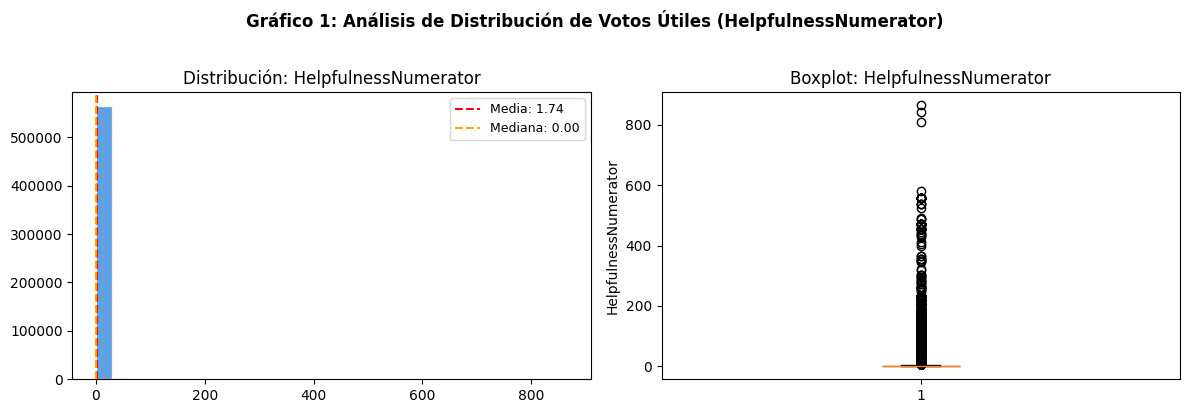

Sesgo (skewness): 37.5216 — asimétrico derecho


In [ ]:
graficar_distribucion(df_limpio, c1, "Gráfico 1: Análisis de Distribución de Votos Útiles (HelpfulnessNumerator)")


Este gráfico combinado detalla la distribución de la variable `HelpfulnessNumerator`, la cual registra cuántos usuarios consideraron que una reseña específica fue de utilidad. El histograma muestra una acumulación masiva de registros pegados al valor cero, mientras que el diagrama de caja (boxplot) vertical expone una densa línea de valores atípicos (outliers) que se extienden de forma continua superando los 800 votos de utilidad.


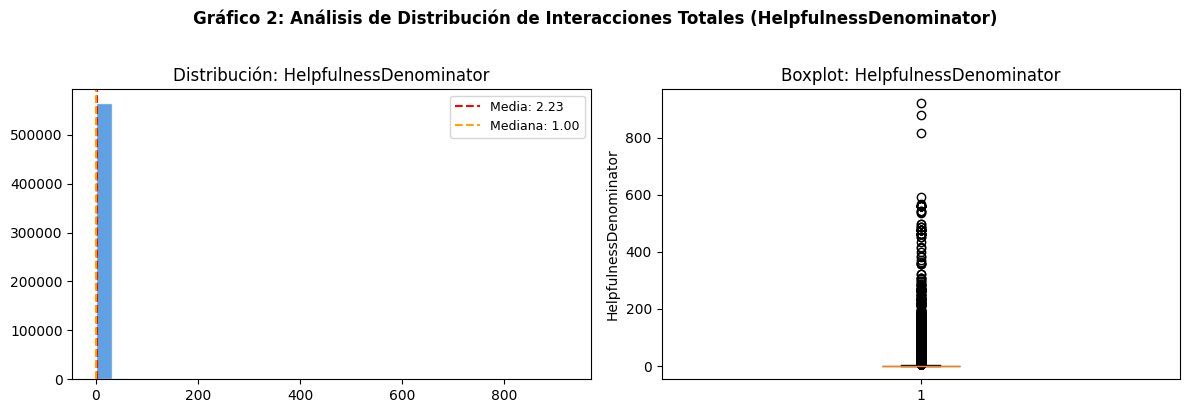

Sesgo (skewness): 32.6329 — asimétrico derecho


In [ ]:
graficar_distribucion(df_limpio, c2, "Gráfico 2: Análisis de Distribución de Interacciones Totales (HelpfulnessDenominator)")

El sesgo a la derecha de 32.6329 y la mediana de 1.00 demuestran que casi la totalidad de las reseñas recibe nulo o muy bajo volumen de interacciones totales (votos a favor o en contra), confirmando que la viralidad de las opiniones está extremadamente concentrada en un grupo minúsculo de usuarios.

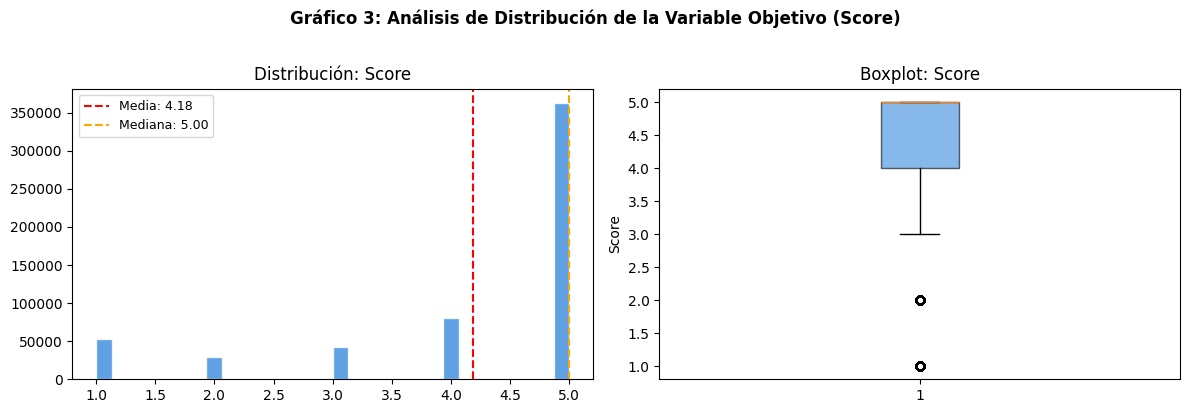

Sesgo (skewness): -1.4610 — asimétrico izquierdo


In [ ]:
graficar_distribucion(df_limpio, c3, "Gráfico 3: Análisis de Distribución de la Variable Objetivo (Score)")

El sesgo a la izquierda de -1.4610 y una mediana de 5.00 confirman que los datos están fuertemente desbalanceados hacia calificaciones excelentes, lo que obligará en la Fase II a usar F1-Score en lugar de Accuracy para evaluar correctamente los modelos de NLP sin sesgos.